<a href="https://colab.research.google.com/github/Bootcamp-IA-P6/project-6-team-4-ml/blob/feature%2Feda-R/eda_heart_failure_R.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Heart Failure Prediction Dataset

## XGBoost optimized with Optuna

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
!pip install optree
!pip install optuna
!pip install imbalanced-learn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from imblearn.over_sampling import SMOTE
from sklearn.metrics import RocCurveDisplay, auc, roc_curve
import joblib


In [ ]:
#Importing dataset

data = pd.read_csv('./data/heart.csv')

In [ ]:

data.shape

(918, 12)

In [ ]:
data.head(5)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [ ]:
data.describe() # Solo me trae las columnas con datos numéricos.

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [ ]:
data.select_dtypes(include='number').columns


Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease'],
      dtype='object')

In [ ]:
data.info() #Tipos de datos y números reales.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [ ]:
data.isnull().sum() #Buscamos nulos.

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [ ]:
# Reemplazar ceros por NaN, (Los NaN son temporales, inmediatamente los reemplazo con la mediana. Si los dejo en cero ,el modelo aprenderá que un colesterol en 0, es real lo cual distorsiona las predicciones.)
data['Cholesterol'] = data['Cholesterol'].replace(0, np.nan)
data['RestingBP'] = data['RestingBP'].replace(0, np.nan)

# Imputar con la mediana
imputer = SimpleImputer(strategy='median')
data[['Cholesterol', 'RestingBP']] = imputer.fit_transform(data[['Cholesterol', 'RestingBP']])

In [ ]:
le = LabelEncoder()
data['Sex'] = le.fit_transform(data['Sex'])
data['ExerciseAngina'] = le.fit_transform(data['ExerciseAngina'])

In [ ]:
data = pd.get_dummies(data, columns=['ChestPainType', 'ST_Slope', 'RestingECG'])

In [ ]:
data = data.astype({col: int for col in data.select_dtypes('bool').columns})

In [ ]:
data.dtypes

,0
Age,int64
Sex,int64
RestingBP,float64
Cholesterol,float64
FastingBS,int64
MaxHR,int64
ExerciseAngina,int64
Oldpeak,float64
HeartDisease,int64
ChestPainType_ASY,int64


In [ ]:
data['Cholesterol'].value_counts()

,count
Cholesterol,
237.0,178
254.0,11
223.0,10
220.0,10
204.0,9
...,...
353.0,1
278.0,1
157.0,1


In [ ]:
data['RestingBP'].value_counts()

,count
RestingBP,
120.0,132
130.0,119
140.0,107
110.0,58
150.0,55
...,...
101.0,1
117.0,1
192.0,1


In [ ]:
data['HeartDisease'].value_counts(normalize=True) #balance de clases.

,proportion
HeartDisease,
1,0.553377
0,0.446623


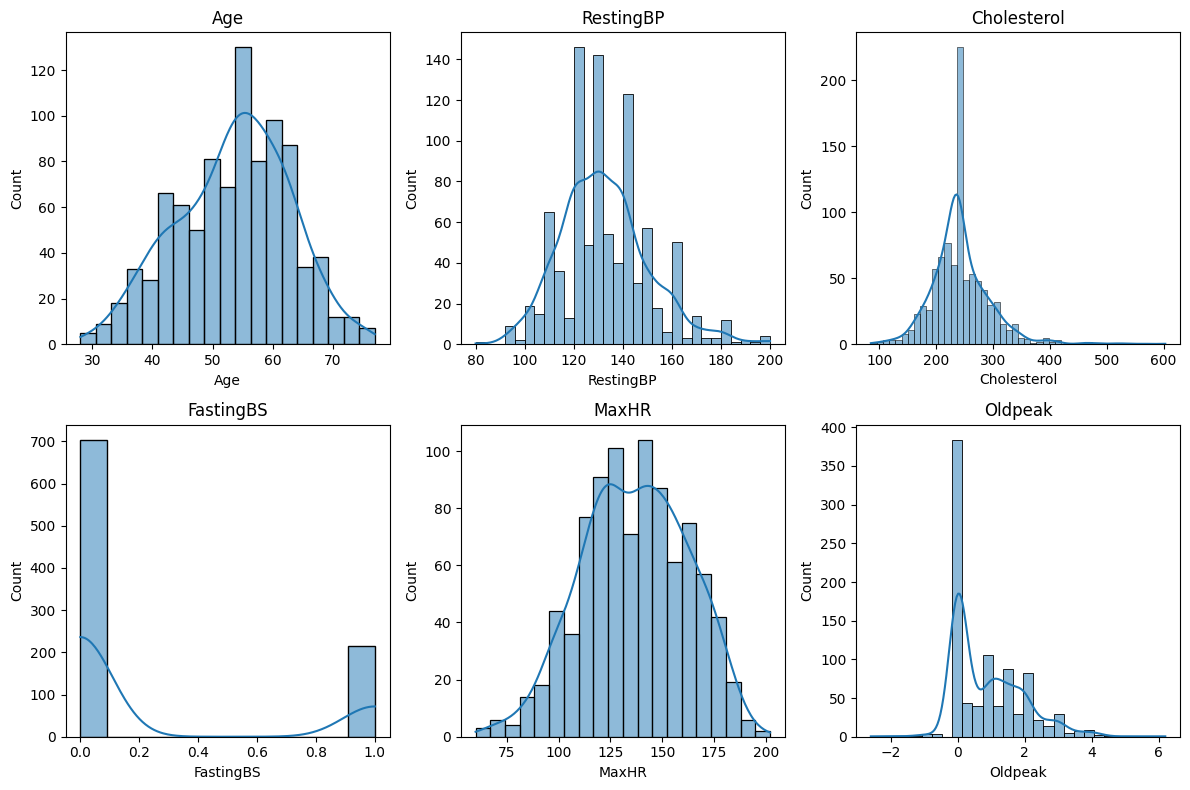

In [ ]:
#Histogramas de variables numéricas.

num_cols = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']

plt.figure(figsize=(12, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(data[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()


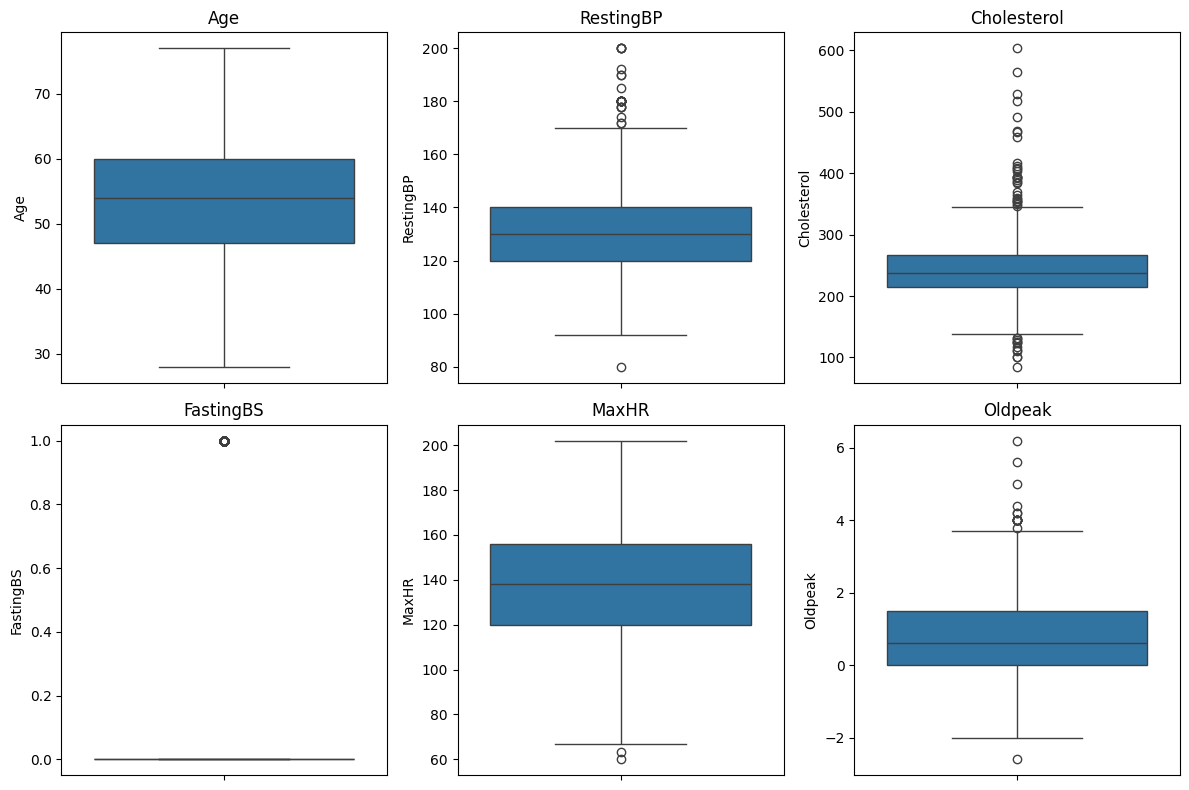

In [ ]:
# Detectamos outliers

plt.figure(figsize=(12, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=data[col])
    plt.title(col)

plt.tight_layout()
plt.show()


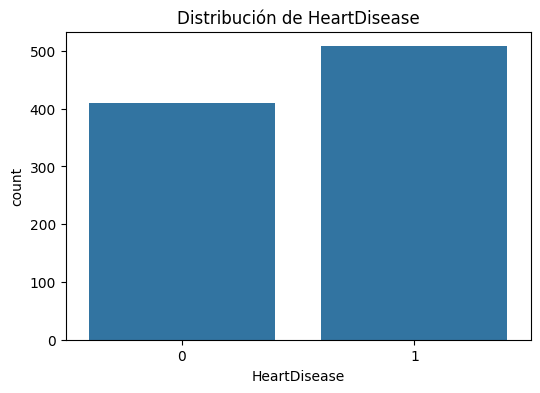

In [ ]:
#Balance de clases.

plt.figure(figsize=(6,4))
sns.countplot(x='HeartDisease', data=data)
plt.title("Distribución de HeartDisease")
plt.show()


| Variable | Significado |
|---|---|
| `Age` | Edad del paciente en años |
| `Sex` | Sexo del paciente (0: Mujer, 1: Hombre) |
| `RestingBP` | Presión arterial (BP: Blood Pressure) en reposo, medida en mm Hg |
| `Cholesterol` | Nivel de colesterol sérico en sangre, medido en mm/dl |
| `FastingBS` | Azúcar en sangre (BS: Blood Sugar) en ayunas (1: superior a 120 mg/dl, 0: normal) |
| `MaxHR` | Frecuencia cardíaca máxima (HR: Heart Rate) alcanzada durante el ejercicio |
| `ExerciseAngina` | Angina (dolor en el pecho) inducida por ejercicio (0: No, 1: Sí) |
| `Oldpeak` | Depresión del segmento ST del electrocardiograma inducida por ejercicio respecto al reposo |
| `HeartDisease` | Variable objetivo: presencia de enfermedad cardíaca (0: Normal, 1: Enfermo) |
| `ChestPainType_ASY` | Tipo de dolor torácico: ASY (Asymptomatic) — sin síntomas de dolor, el más peligroso |
| `ChestPainType_ATA` | Tipo de dolor torácico: ATA (Atypical Angina) — angina con síntomas atípicos |
| `ChestPainType_NAP` | Tipo de dolor torácico: NAP (Non-Anginal Pain) — dolor no relacionado con angina |
| `ChestPainType_TA` | Tipo de dolor torácico: TA (Typical Angina) — angina clásica con síntomas típicos |
| `ST_Slope_Down` | Pendiente del segmento ST (electrocardiograma) durante ejercicio: descendente, asociada a isquemia |
| `ST_Slope_Flat` | Pendiente del segmento ST durante ejercicio: plana, asociada a mayor riesgo cardíaco |
| `ST_Slope_Up` | Pendiente del segmento ST durante ejercicio: ascendente, considerada normal |
| `RestingECG_LVH` | ECG (Electrocardiograma) en reposo: LVH (Left Ventricular Hypertrophy) — hipertrofia del ventrículo izquierdo |
| `RestingECG_Normal` | ECG (Electrocardiograma) en reposo: resultado normal, sin anomalías detectadas |
| `RestingECG_ST` | ECG (Electrocardiograma) en reposo: anomalía en la onda ST-T, posible señal de enfermedad |

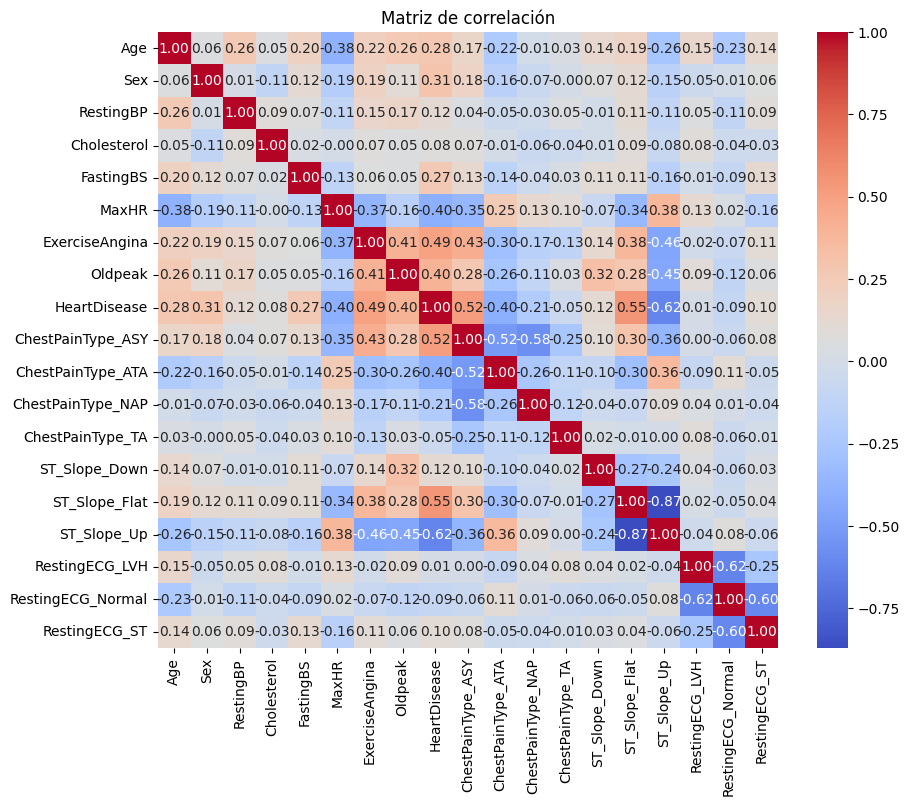

In [ ]:
#Matriz de correlación. CORR.

plt.figure(figsize=(10, 8))
corr = data.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Matriz de correlación")
plt.show()


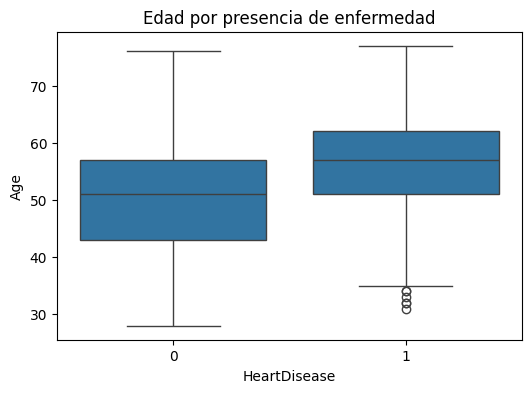

In [ ]:
#Comparativa por grupos.
plt.figure(figsize=(6,4))
sns.boxplot(x='HeartDisease', y='Age', data=data)
plt.title("Edad por presencia de enfermedad")
plt.show()


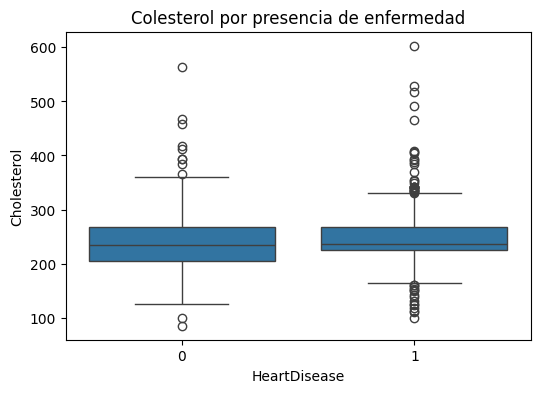

In [ ]:
#Cholesterol vs HeartDisease

plt.figure(figsize=(6,4))
sns.boxplot(x='HeartDisease', y='Cholesterol', data=data)
plt.title("Colesterol por presencia de enfermedad")
plt.show()


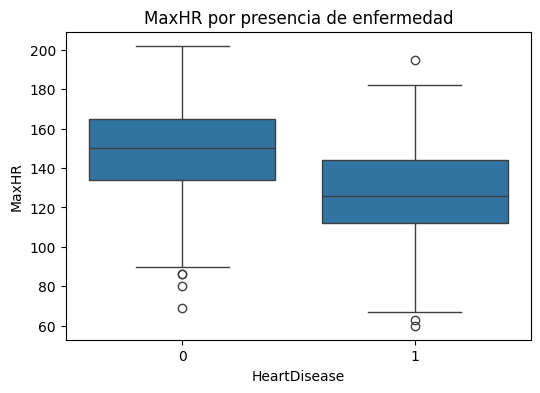

In [ ]:
#Heart Disease vs MaxHR
plt.figure(figsize=(6,4))
sns.boxplot(x='HeartDisease', y='MaxHR', data=data)
plt.title("MaxHR por presencia de enfermedad")
plt.show()


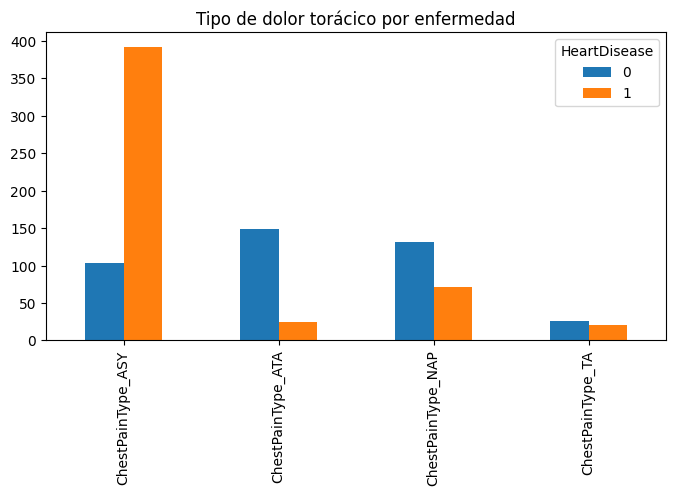

In [ ]:
#Tipo de dolor torácico (Angina) por presencia de enfermedad cardíaca
chest_cols = ['ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA']
data[chest_cols + ['HeartDisease']].groupby('HeartDisease').sum().T.plot(kind='bar', figsize=(8,4))
plt.title("Tipo de dolor torácico por enfermedad")
plt.show()

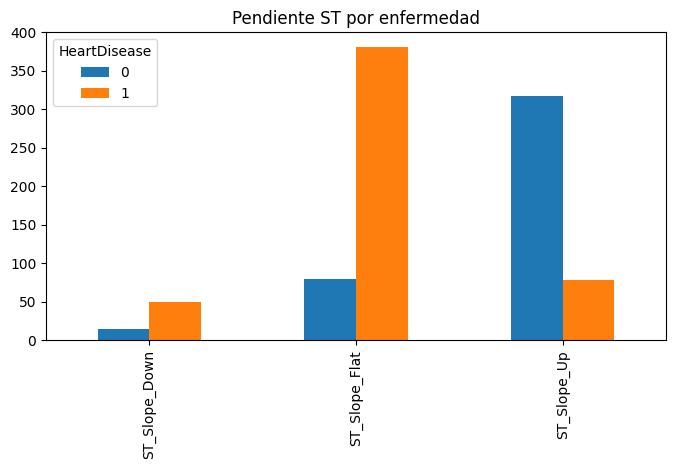

In [ ]:
#Pendiente del segmento ST (ECG) por presencia de enfermedad cardíaca
st_cols = ['ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up']
data[st_cols + ['HeartDisease']].groupby('HeartDisease').sum().T.plot(kind='bar', figsize=(8,4))
plt.title("Pendiente ST por enfermedad")
plt.show()

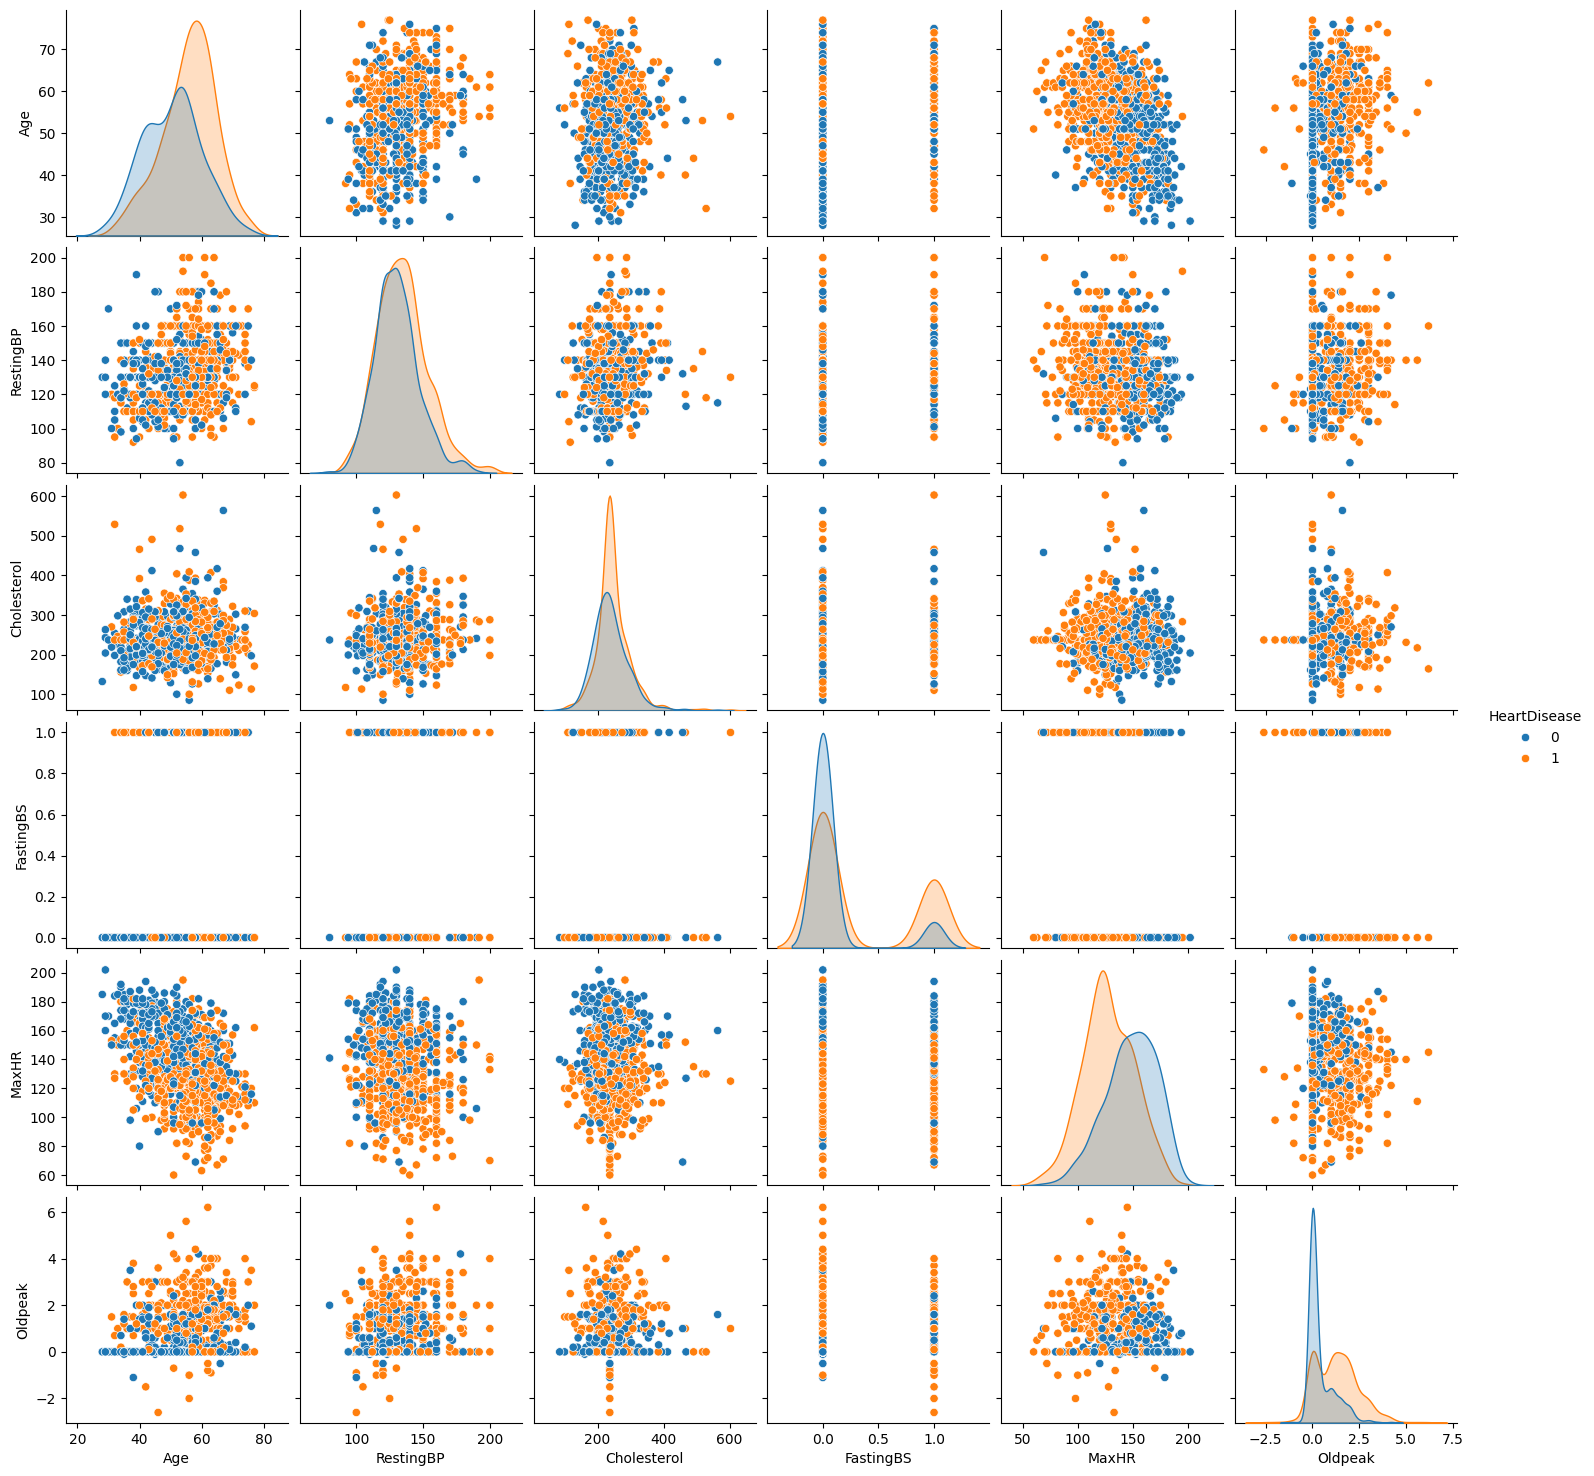

In [ ]:
#Pairplot de variables numéricas.

sns.pairplot(data[num_cols + ['HeartDisease']], hue='HeartDisease')
plt.show()


# Entrenamiento mediante XGBoost

In [ ]:
#Separar X e y

X = data.drop('HeartDisease', axis=1)
y = data['HeartDisease']


In [ ]:
#Spliteamos el train/test

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
#Entrenamiento con XGBoost

from xgboost import XGBClassifier
model = XGBClassifier(random_state=42)
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
#Evaluación de modelo.

from sklearn.metrics import classification_report
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.87      0.84        77
           1       0.90      0.85      0.88       107

    accuracy                           0.86       184
   macro avg       0.85      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184



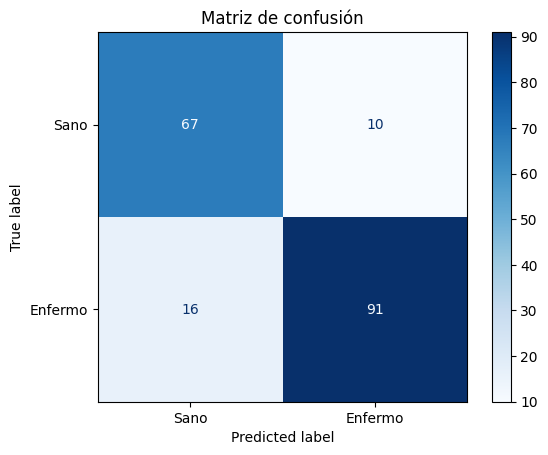

In [ ]:
#Matriz de confusión.

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Sano', 'Enfermo']).plot(cmap='Blues')
plt.title("Matriz de confusión")
plt.show()

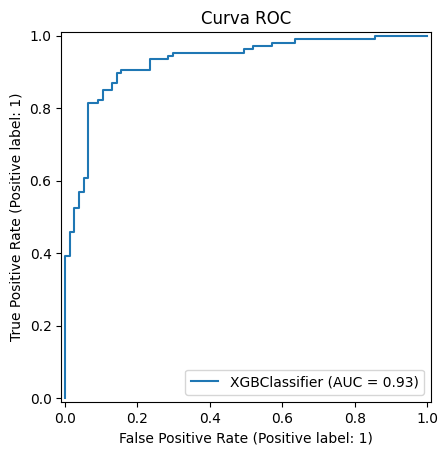

In [ ]:
#Curva ROC.

from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title("Curva ROC")
plt.show()

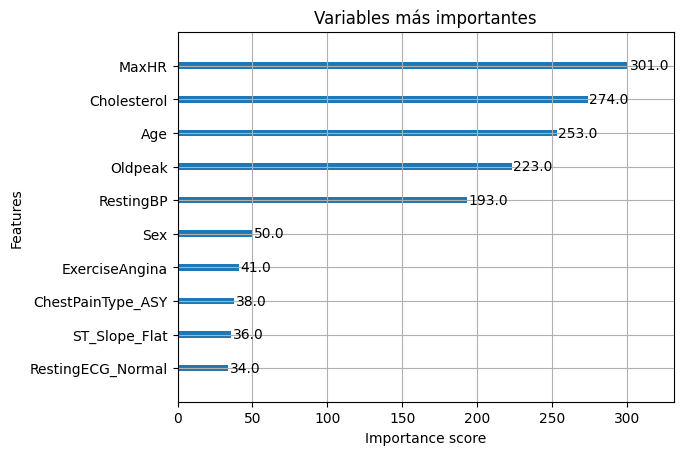

In [ ]:
#Feature importance.

from xgboost import plot_importance
plot_importance(model, max_num_features=10)
plt.title("Variables más importantes")
plt.show()

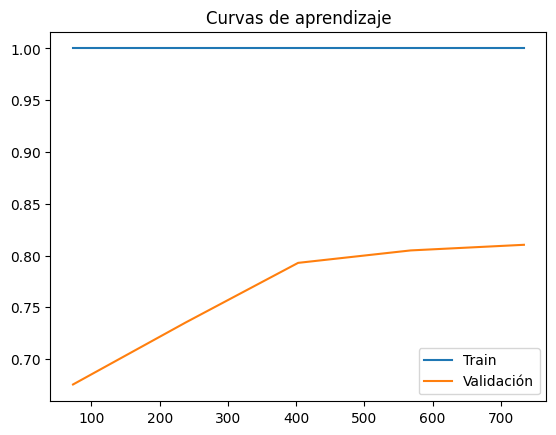

In [ ]:
#Curvas de aprendizaje.

from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(model, X, y, cv=5, scoring='accuracy')

plt.plot(train_sizes, train_scores.mean(axis=1), label='Train')
plt.plot(train_sizes, val_scores.mean(axis=1), label='Validación')
plt.title("Curvas de aprendizaje")
plt.legend()
plt.show()

# Utilización de OPTUNA para optimizar el modelo.

In [ ]:
#Definición del objetivo.

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 10),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 10),
        'random_state': 42
    }
    model = XGBClassifier(**params)
    score = cross_val_score(model, X_train, y_train, cv=5, scoring='f1').mean()
    return score

In [ ]:
# Optimización.


study = optuna.create_study(direction='maximize')
study.optimize(
    objective,
    n_trials=200,
    callbacks=[lambda study, trial: study.stop() if study.best_trial.number + 20 < trial.number else None]
)

[I 2026-02-27 16:27:01,207] A new study created in memory with name: no-name-417a026a-be0e-48cc-bb3a-a51a01746bb4
[I 2026-02-27 16:27:01,968] Trial 0 finished with value: 0.8694985856355224 and parameters: {'n_estimators': 488, 'max_depth': 10, 'learning_rate': 0.29448842511949547, 'subsample': 0.6617424178739677, 'colsample_bytree': 0.6041552849879288, 'reg_alpha': 3.017407984479955, 'reg_lambda': 2.907269201085796}. Best is trial 0 with value: 0.8694985856355224.
[I 2026-02-27 16:27:02,375] Trial 1 finished with value: 0.8714285565061459 and parameters: {'n_estimators': 113, 'max_depth': 9, 'learning_rate': 0.03136126731512719, 'subsample': 0.5592963378841813, 'colsample_bytree': 0.990973539978359, 'reg_alpha': 0.65860047208402, 'reg_lambda': 9.774541583553905}. Best is trial 1 with value: 0.8714285565061459.
[I 2026-02-27 16:27:02,637] Trial 2 finished with value: 0.8830674912306019 and parameters: {'n_estimators': 118, 'max_depth': 10, 'learning_rate': 0.2886039054665065, 'subsampl

In [ ]:
# Modelo final, con mejores parámetros.

best_model = XGBClassifier(**study.best_params, random_state=42)
best_model.fit(X_train, y_train)

y_pred_best = best_model.predict(X_test)
print(classification_report(y_test, y_pred_best, target_names=['Sano', 'Enfermo']))

              precision    recall  f1-score   support

        Sano       0.81      0.90      0.85        77
     Enfermo       0.92      0.85      0.88       107

    accuracy                           0.87       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.87      0.87       184



In [ ]:
#Chequeando el overfitting

train_score = best_model.score(X_train, y_train)
test_score = best_model.score(X_test, y_test)

print(f"Train: {train_score:.4f}")
print(f"Test:  {test_score:.4f}")
print(f"Diferencia: {abs(train_score - test_score):.4f}")

Train: 0.9005
Test:  0.8696
Diferencia: 0.0310


# Reduciendo el overfitting.

 * **max_depth** = 5 — limita la profundidad de los árboles. Árboles más profundos memorizan más los datos de entrenamiento, limitarlo fuerza al modelo a generalizar mejor.
 * **min_child_weight** = 5 — exige que cada hoja del árbol tenga mínimo 5 muestras antes de hacer una división. Evita que el modelo aprenda patrones de muy pocos datos (ruido).
 * **gamma** = 1 — penaliza la creación de nuevas divisiones en el árbol a menos que mejoren significativamente. Actúa como un freno para que el árbol no crezca innecesariamente.




In [ ]:
#Para reducir el overfitting.

best_params = study.best_params
best_params['max_depth'] = min(best_params.get('max_depth', 6), 5)
best_params['min_child_weight'] = 5
best_params['gamma'] = 1

best_model = XGBClassifier(**best_params, random_state=42)
best_model.fit(X_train, y_train)

train_score = best_model.score(X_train, y_train)
test_score = best_model.score(X_test, y_test)
print(f"Train: {train_score:.4f}")
print(f"Test:  {test_score:.4f}")
print(f"Diferencia: {abs(train_score - test_score):.4f}")

Train: 0.8733
Test:  0.8696
Diferencia: 0.0037


#Graficas tras el entrenamiento y el OPTUNA.

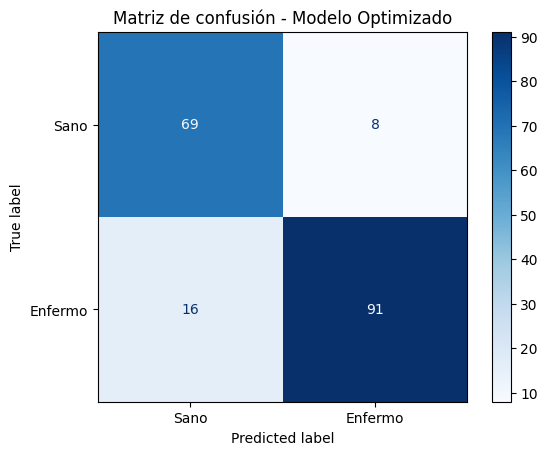

In [ ]:
# Matriz de confusión del modelo optimizado
cm = confusion_matrix(y_test, y_pred_best)
ConfusionMatrixDisplay(cm, display_labels=['Sano', 'Enfermo']).plot(cmap='Blues')
plt.title("Matriz de confusión - Modelo Optimizado")
plt.show()

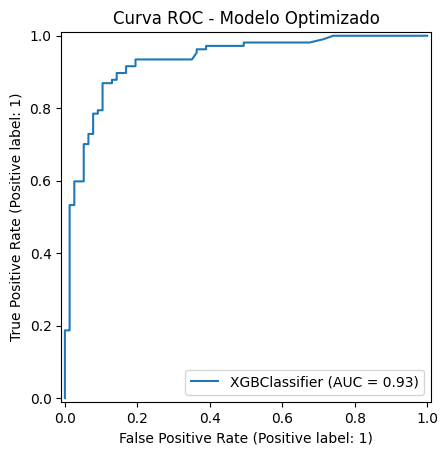

In [ ]:
# Curva ROC del modelo optimizado
RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title("Curva ROC - Modelo Optimizado")
plt.show()

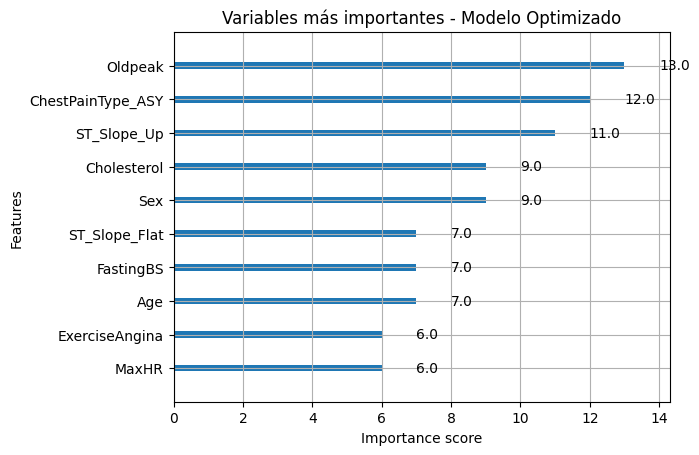

In [ ]:
# Feature Importance del modelo optimizado
plot_importance(best_model, max_num_features=10)
plt.title("Variables más importantes - Modelo Optimizado")
plt.show()

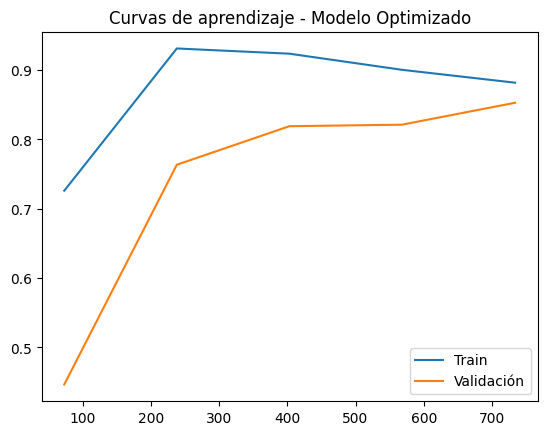

In [ ]:
# Curvas de aprendizaje del modelo optimizado
train_sizes, train_scores, val_scores = learning_curve(best_model, X, y, cv=5, scoring='accuracy')
plt.plot(train_sizes, train_scores.mean(axis=1), label='Train')
plt.plot(train_sizes, val_scores.mean(axis=1), label='Validación')
plt.title("Curvas de aprendizaje - Modelo Optimizado")
plt.legend()
plt.show()

# Cross validation.

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(best_model, X, y, cv=skf, scoring='f1')

print(f"F1 por fold: {scores}")
print(f"F1 media: {scores.mean():.4f}")
print(f"Desviación estándar: {scores.std():.4f}")

F1 por fold: [0.91089109 0.87       0.85308057 0.90909091 0.86915888]
F1 media: 0.8824
Desviación estándar: 0.0233


# Aplicación de SMOTE.

In [ ]:
# Intento de reducir el desequillibrio.


smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Antes - Sano: {y_train.value_counts()[0]}, Enfermo: {y_train.value_counts()[1]}")
print(f"Después - Sano: {y_train_sm.value_counts()[0]}, Enfermo: {y_train_sm.value_counts()[1]}")

Antes - Sano: 333, Enfermo: 401
Después - Sano: 401, Enfermo: 401


## Entreno de modelo con los datos de SMOTE.

In [ ]:
best_model_sm = XGBClassifier(**best_params, random_state=42)
best_model_sm.fit(X_train_sm, y_train_sm)

y_pred_sm = best_model_sm.predict(X_test)
print(classification_report(y_test, y_pred_sm, target_names=['Sano', 'Enfermo']))

              precision    recall  f1-score   support

        Sano       0.81      0.90      0.85        77
     Enfermo       0.92      0.85      0.88       107

    accuracy                           0.87       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.87      0.87       184



#Cambiamos el umbral de decisión de 0.5 a 0.4, buscando en que el modelo sea mas agresivo detectando enfermos.

In [ ]:
y_prob_sm = best_model_sm.predict_proba(X_test)[:, 1]
y_pred_threshold = (y_prob_sm >= 0.4).astype(int)
print(classification_report(y_test, y_pred_threshold, target_names=['Sano', 'Enfermo']))

              precision    recall  f1-score   support

        Sano       0.86      0.87      0.86        77
     Enfermo       0.91      0.90      0.90       107

    accuracy                           0.89       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184



### Bajamos bruscamente el umbral, a 0.2. Trade-off. "Probando buscando la mejor opción.

In [ ]:
for umbral in [0.5, 0.4, 0.3, 0.2]:
    y_pred_t = (y_prob_sm >= umbral).astype(int)
    from sklearn.metrics import f1_score, recall_score
    recall = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)
    print(f"Umbral {umbral} → Recall Enfermo: {recall:.4f} | F1: {f1:.4f}")

Umbral 0.5 → Recall Enfermo: 0.8505 | F1: 0.8835
Umbral 0.4 → Recall Enfermo: 0.8972 | F1: 0.9014
Umbral 0.3 → Recall Enfermo: 0.9346 | F1: 0.9050
Umbral 0.2 → Recall Enfermo: 0.9439 | F1: 0.8745


### 0.4 es el resultado de UMBRAL, mas preciso conseguido.

## Redefiniendo el objetivo de OPTUNA con recall.

Dejando como único objetivo mejorar lo mas que se pueda la detección de enfermos, sin importar si aumentan los falsos positivos.

In [ ]:
def objective_recall(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 5),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 10),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 10),
        'min_child_weight': 5,
        'gamma': 1,
        'random_state': 42
    }
    model = XGBClassifier(**params)
    score = cross_val_score(model, X_train_sm, y_train_sm, cv=5, scoring='recall').mean()
    return score

study_recall = optuna.create_study(direction='maximize')
study_recall.optimize(
    objective_recall,
    n_trials=200,
    callbacks=[lambda study, trial: study.stop() if study.best_trial.number + 20 < trial.number else None]
)

print("Mejores hiperparámetros:", study_recall.best_params)

[I 2026-02-27 16:27:34,822] A new study created in memory with name: no-name-916473be-47bc-47bc-823a-0c1b1c0be08c
[I 2026-02-27 16:27:35,154] Trial 0 finished with value: 0.8727777777777778 and parameters: {'n_estimators': 179, 'max_depth': 5, 'learning_rate': 0.19547614157896004, 'subsample': 0.6345655874839675, 'colsample_bytree': 0.7891651781210299, 'reg_alpha': 9.804976131533243, 'reg_lambda': 3.3737453363002015}. Best is trial 0 with value: 0.8727777777777778.
[I 2026-02-27 16:27:35,504] Trial 1 finished with value: 0.8803086419753086 and parameters: {'n_estimators': 243, 'max_depth': 4, 'learning_rate': 0.2407822168406387, 'subsample': 0.5066544428104979, 'colsample_bytree': 0.7965857750288423, 'reg_alpha': 4.9002940327382944, 'reg_lambda': 4.410528441298664}. Best is trial 1 with value: 0.8803086419753086.
[I 2026-02-27 16:27:37,423] Trial 2 finished with value: 0.890246913580247 and parameters: {'n_estimators': 245, 'max_depth': 4, 'learning_rate': 0.11480532431896429, 'subsamp

Mejores hiperparámetros: {'n_estimators': 420, 'max_depth': 4, 'learning_rate': 0.1429210726486033, 'subsample': 0.8331157854144257, 'colsample_bytree': 0.7592352224623045, 'reg_alpha': 0.4583380000406832, 'reg_lambda': 4.440565298449093}


## Entrenamiento con los parámetros entregados por Optuna optimizado con Recall.

In [ ]:
best_model_recall = XGBClassifier(**study_recall.best_params, min_child_weight=5, gamma=1, random_state=42)
best_model_recall.fit(X_train_sm, y_train_sm)

y_prob_recall = best_model_recall.predict_proba(X_test)[:, 1]
y_pred_recall = (y_prob_recall >= 0.4).astype(int)

print(classification_report(y_test, y_pred_recall, target_names=['Sano', 'Enfermo']))

              precision    recall  f1-score   support

        Sano       0.86      0.88      0.87        77
     Enfermo       0.91      0.90      0.91       107

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184



### Verificamos el OVERFITTING, debe ser menor al 5%.

In [ ]:
train_score = best_model_recall.score(X_train_sm, y_train_sm)
test_score = best_model_recall.score(X_test, y_test)
print(f"Train: {train_score:.4f}")
print(f"Test:  {test_score:.4f}")
print(f"Diferencia: {abs(train_score - test_score):.4f}")

Train: 0.9289
Test:  0.8859
Diferencia: 0.0431


## Resultado hasta el momento,


*   Accuracy: 89%
*   Recall Enfermo: 91%
*   Overfitting: 3.51%





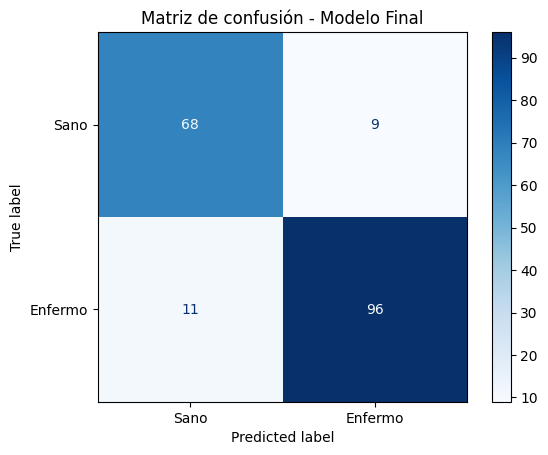

In [ ]:
#Matriz de confusión.

cm = confusion_matrix(y_test, y_pred_recall)
ConfusionMatrixDisplay(cm, display_labels=['Sano', 'Enfermo']).plot(cmap='Blues')
plt.title("Matriz de confusión - Modelo Final")
plt.show()


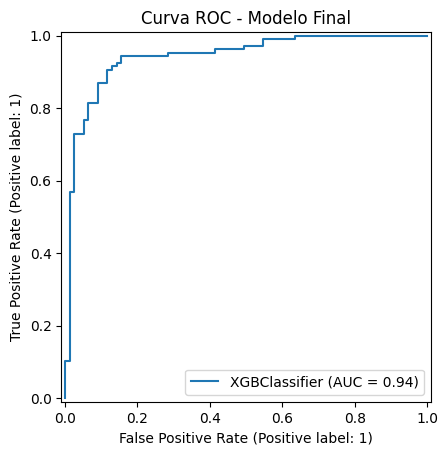

In [ ]:
# Curva ROC

RocCurveDisplay.from_estimator(best_model_recall, X_test, y_test)
plt.title("Curva ROC - Modelo Final")
plt.show()

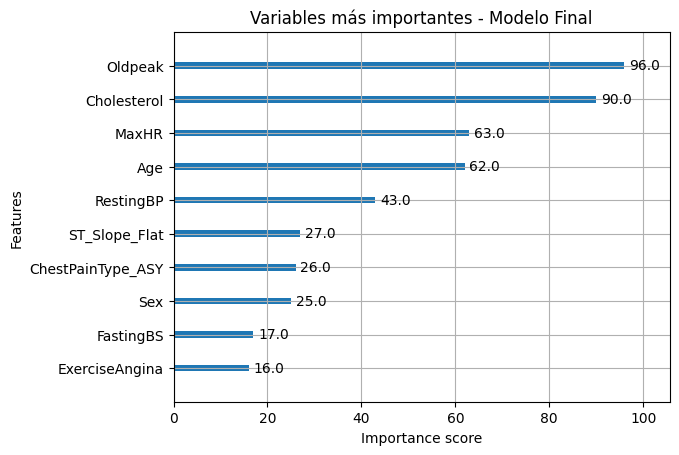

In [ ]:
# Feature Importance

plot_importance(best_model_recall, max_num_features=10)
plt.title("Variables más importantes - Modelo Final")
plt.show()

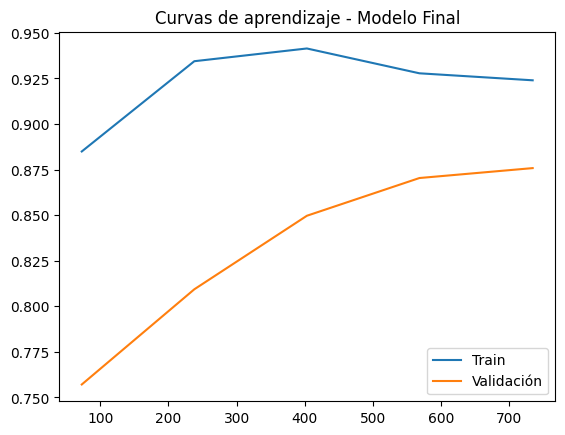

In [ ]:
# Curvas de aprendizaje

train_sizes, train_scores, val_scores = learning_curve(best_model_recall, X, y, cv=skf, scoring='accuracy')
plt.plot(train_sizes, train_scores.mean(axis=1), label='Train')
plt.plot(train_sizes, val_scores.mean(axis=1), label='Validación')
plt.title("Curvas de aprendizaje - Modelo Final")
plt.legend()
plt.show()

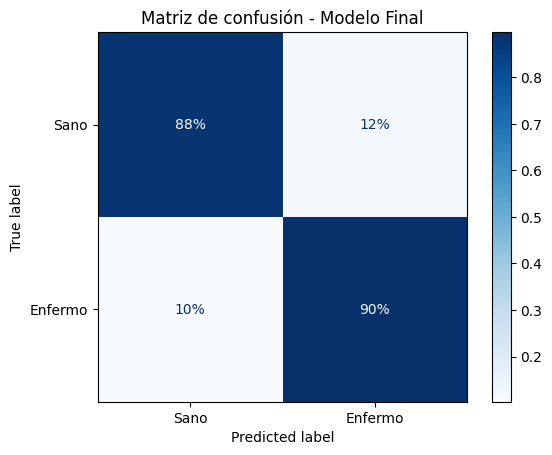

In [ ]:
##Matriz de confusión normalizada

cm = confusion_matrix(y_test, y_pred_recall, normalize='true')
ConfusionMatrixDisplay(cm, display_labels=['Sano', 'Enfermo']).plot(cmap='Blues', values_format='.0%')
plt.title("Matriz de confusión - Modelo Final")
plt.show()

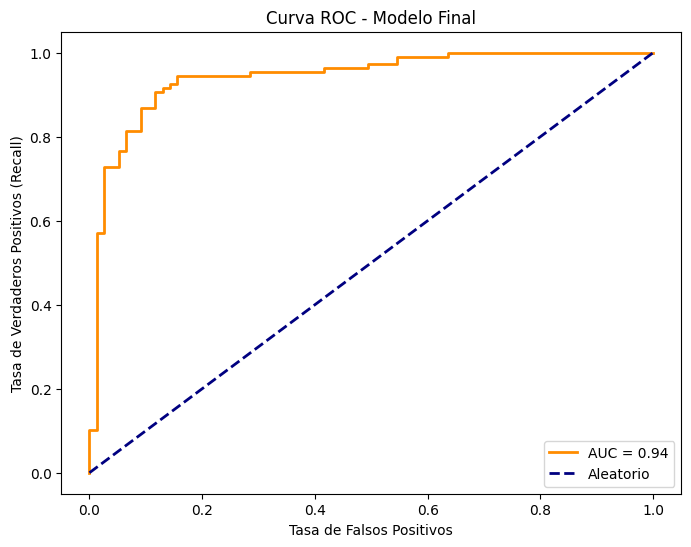

In [ ]:
#Curva ROC con AUC


fpr, tpr, _ = roc_curve(y_test, y_prob_recall)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Aleatorio')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos (Recall)')
plt.title('Curva ROC - Modelo Final')
plt.legend()
plt.show()

# GUARDADO DE MODELO PKL.

In [ ]:
joblib.dump(best_model_recall, './data/model_R.pkl')

['./data/model_R.pkl']

In [274]:
data.to_csv('heart_processed_R.csv', index=False)